In [ ]:
# 1. Import Libraries

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# 2. Load MNST Dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [ ]:
# 3. Data Pre-Processing

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Flatten
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("After preprocessing:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

After preprocessing:
X_train: (60000, 784)
y_train: (60000, 10)


In [ ]:
# 4. Feed Forward: ANN (4 hidden layer)
# RELU activation function

model = Sequential()

# Input Layer
model.add(Dense(512, activation='relu', input_shape=(784,)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden Layer 1
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden Layer 3
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())

# Hidden Layer 4
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 5.BackPropagation

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


In [ ]:
# 6. Train

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128
)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.7525 - loss: 0.8182 - val_accuracy: 0.9553 - val_loss: 0.1477
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9468 - loss: 0.1821 - val_accuracy: 0.9657 - val_loss: 0.1159
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9594 - loss: 0.1361 - val_accuracy: 0.9701 - val_loss: 0.1025
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9650 - loss: 0.1149 - val_accuracy: 0.9699 - val_loss: 0.0996
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9687 - loss: 0.1002 - val_accuracy: 0.9745 - val_loss: 0.0861
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9739 - loss: 0.0854 - val_accuracy: 0.9764 - val_loss: 0.0818
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9761 - loss: 0.0786 - val_accuracy: 0.9772 - val_loss: 0.0803
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9762 - loss: 0.0727 - val_ac

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9783 - loss: 0.0788
Test Accuracy: 0.9822999835014343
Test Loss: 0.06590007245540619


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

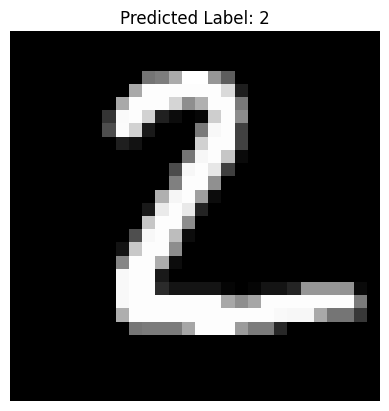

In [ ]:
index = 1
plt.imshow(X_test[index].reshape(28,28), cmap='gray')
plt.title("Predicted Label: " + str(y_pred_classes[index]))
plt.axis('off')
